In [1]:
import pandas as pd 
import os 
from pipeline_runner import run_pipeline
import warnings
warnings.filterwarnings("ignore", message="The figure layout has changed to tight",category=UserWarning,)
warnings.filterwarnings("ignore", message="Geometry is in a geographic CRS.*Results from 'centroid' are likely incorrect.*",category=UserWarning,)
from visualizations_and_filtering import apply_filters
pd.set_option("display.max_columns", None)
import numpy as np
from visualizations_and_filtering import run_from_bundle
from core import Pipeline
from machine_learning_and_visualisations import register_machine_learning_and_visualisations

In [2]:
filename = "otodom_offers.csv"
filepath = (os.getcwd() + f"\\data\\{filename}").replace("\\", "/")
pd.read_csv(f"data/{filename}").head().drop(["offer_url", "Adres", "Tytuł"], axis=1)

,Cena,Czynsz,Informacje dodatkowe,Liczba pokoi,Opis,Piętro,Powierzchnia,Rok budowy,Rynek,Stan wykończenia,Winda
0,735 000 zł,700 zł,"internet, telewizja kablowa, drzwi / okna anty...",3,"Jasne,słoneczne, wykończone, po remoncie miesz...",2,46.5,1970,wtórny,do zamieszkania,tak
1,498 000 zł,brak danych,"monitoring / ochrona, meble, lodówka, piekarni...",1,"Jeśli szukasz gotowego, urządzonego lokalu do ...",1,31.22,2018,wtórny,do zamieszkania,tak
2,999 000 zł,1000 zł,"monitoring / ochrona, domofon / wideofon, mebl...",3,Mieszkanie gotowe do zamieszkania – ul. Jana K...,3,63.08,2017,wtórny,do zamieszkania,tak
3,755 722 zł,brak danych,"garaż/miejsce parkingowe, balkon, winda",2,2-pokojowe mieszkanie numer 41 na 5. piętrze w...,5,43.81,2026,pierwotny,do wykończenia,tak
4,653 000 zł,600 zł,"domofon / wideofon, teren zamknięty, balkon, p...",3,Jeśli szukasz funkcjonalnego i jasnego mieszka...,2,48.39,1969,wtórny,do remontu,tak


In [3]:
bundle = run_pipeline(data="otodom_offers.csv", log_every=30)
bundle.get("meta")["error"]

[SPATIAL] Rekordów z poprawnymi współrzędnymi: 14353 / 16052
[SPATIAL] Wczytuję geojsony z: geojson
[SPATIAL] Liczę odległości BallTree...
[SPATIAL] Spatial join z dzielnicami...
[SPATIAL] Liczę cenę za m2...
[SPATIAL] Cechy przestrzenne policzone, zapisano snapshot: data\otodom_offers_api_14353.csv
[BIN] Start binarizacji kolumny 'Informacje dodatkowe'


"additional_info_binarization: kolumna docelowa 'balkon' już istnieje w data. Źródłowa kategoria: 'balkon'."

In [4]:
if "offer_url" in bundle.get("data").columns:
    bundle.get('data').drop("offer_url", axis=1, inplace=True)
if "Adres" in bundle.get("data").columns:
    bundle.get('data').drop("Adres", axis=1, inplace=True)
bundle.get('data').head()

,Cena,Czynsz,Informacje dodatkowe,Liczba pokoi,Opis,Piętro,Powierzchnia,Rok budowy,Rynek,Stan wykończenia,Tytuł,Szerokosc_geo,Dlugosc_geo,proba_geokodowania,Odleglosc_metro_m1,Odleglosc_metro_m2,Odleglosc_tereny_zielone,Odleglosc_supermarket,Dzielnica,Cena_za_m2,balkon,boiska_sportowe,czujnik_dymu,domofon,drzwi,dwupoziomowe,garaz,internet,klimatyzacja,komorki_lokatorskie,kuchenka,lodowka,meble,miejsce_parkingowe,miejsce_parkingowe_naziemne,miejsce_parkingowe_podziemne,monitoring,ochrona,oddzielna_kuchnia,ogrodek,okna_antywlamaniowe,piekarnik,piwnica,plac_zbaw,pom_uzytkowe,pomieszczenie_na_rowery,pralka,przyjazny_dla_osob_niepelnosprawnych,rolety_antywlamaniowe,silownia,strefa_wypoczynku,system_alarmowy,taras,telefon,telewizja_kablowa,telewizor,teren_zamkniety,wideofon,winda,zmywarka
0,735000.0,700 zł,"internet, telewizja kablowa, drzwi / okna anty...",3,"Jasne,słoneczne, wykończone, po remoncie miesz...",2,46.5,1970,wtórny,do zamieszkania,3 pokoje z oddzielną kuchnią po remoncie.,52.173802,21.003743,1,1541.658440,6417.386168,113.690515,25.362407,Mokotów,15806.451613,1,0,0,1,1,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,1
1,498000.0,brak danych,"monitoring / ochrona, meble, lodówka, piekarni...",1,"Jeśli szukasz gotowego, urządzonego lokalu do ...",1,31.22,2018,wtórny,do zamieszkania,Apartament inwestycyjny z gwarancją najmu,52.186944,20.925278,1,6072.822653,5783.949230,171.962258,1240.248302,Włochy,15951.313261,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,999000.0,1000 zł,"monitoring / ochrona, domofon / wideofon, mebl...",3,Mieszkanie gotowe do zamieszkania – ul. Jana K...,3,63.08,2017,wtórny,do zamieszkania,Apartament na luksusowym osiedlu nad rzeką,52.312820,21.051209,1,6642.540269,2311.987562,70.621785,558.382914,Białołęka,15837.032340,0,0,0,1,0,0,1,0,0,0,0,1,1,1,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1
3,755722.0,brak danych,"garaż/miejsce parkingowe, balkon, winda",2,2-pokojowe mieszkanie numer 41 na 5. piętrze w...,5,43.81,2026,pierwotny,do wykończenia,2-pokojowe mieszkanie 43m2 + balkon Bezpośrednio,52.240421,21.085254,1,5219.074896,2978.287597,236.044987,406.525938,Praga Południe,17249.988587,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,653000.0,600 zł,"domofon / wideofon, teren zamknięty, balkon, p...",3,Jeśli szukasz funkcjonalnego i jasnego mieszka...,2,48.39,1969,wtórny,do remontu,"Na sprzedaż 3-pokoje na Pradze-Południe, ul. B...",52.275063,21.082863,1,6323.784113,1708.494766,231.880529,756.388088,Targówek,13494.523662,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0


# Data exploration and Filtering

### CONFIG

In [5]:
# podejrzenie braków danych
bundle.get('data').replace("brak danych", np.nan).isna().sum().nlargest(25)

Czynsz                      7945
Stan wykończenia            2106
Dzielnica                   2040
Cena                        1818
Cena_za_m2                  1818
Szerokosc_geo               1699
Dlugosc_geo                 1699
Odleglosc_metro_m1          1699
Odleglosc_metro_m2          1699
Odleglosc_tereny_zielone    1699
Odleglosc_supermarket       1699
Rok budowy                  1389
Piętro                       928
Informacje dodatkowe         520
Liczba pokoi                 345
Powierzchnia                 345
Rynek                        345
Tytuł                        341
Opis                           0
proba_geokodowania             0
balkon                         0
boiska_sportowe                0
czujnik_dymu                   0
domofon                        0
drzwi                          0
dtype: int64


=== Raport wartości brakujących (po Filtrowaniu) ===
Wiersze: 12,141 | Kolumny: 56
Kolumny z brakami danych: 0 | Całkowita liczba NaN's: 0


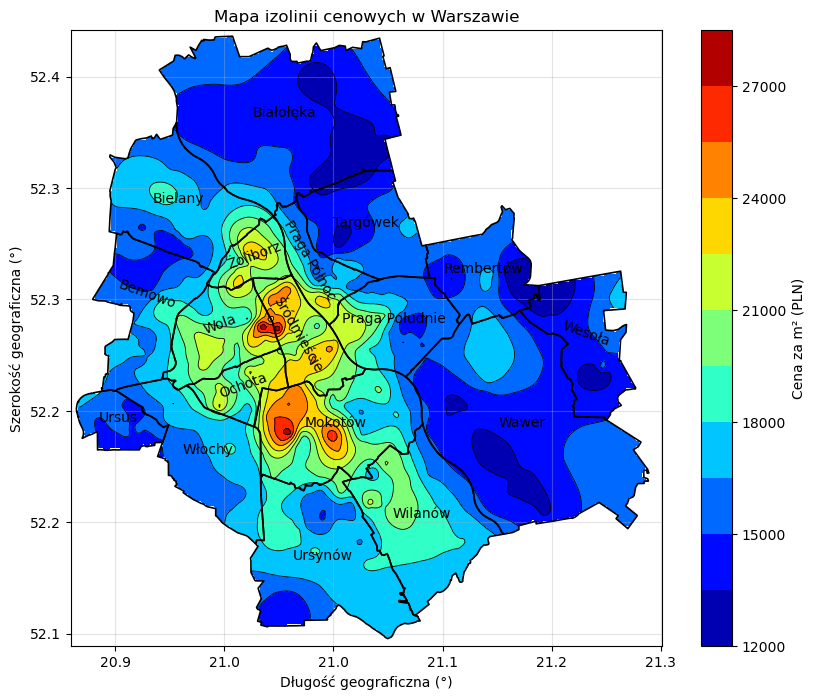

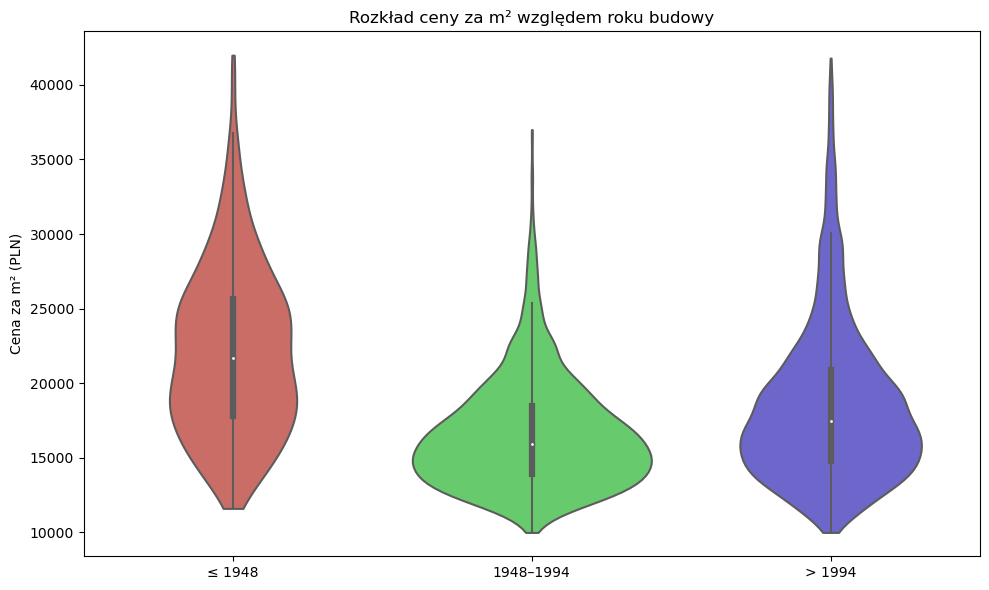

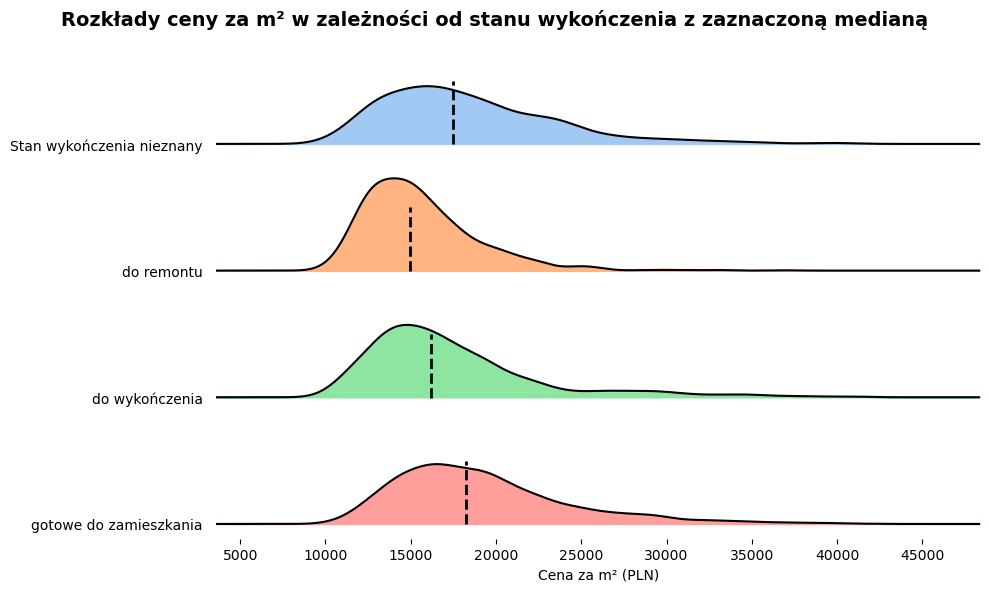

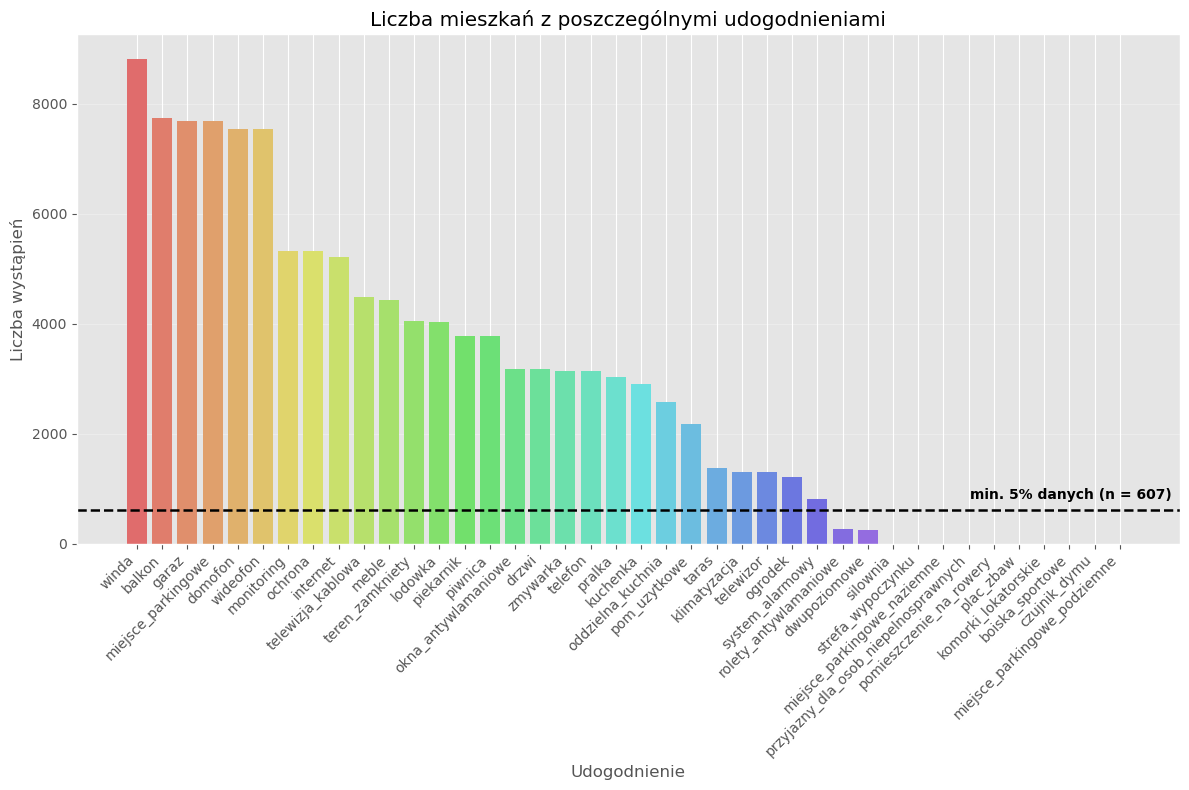

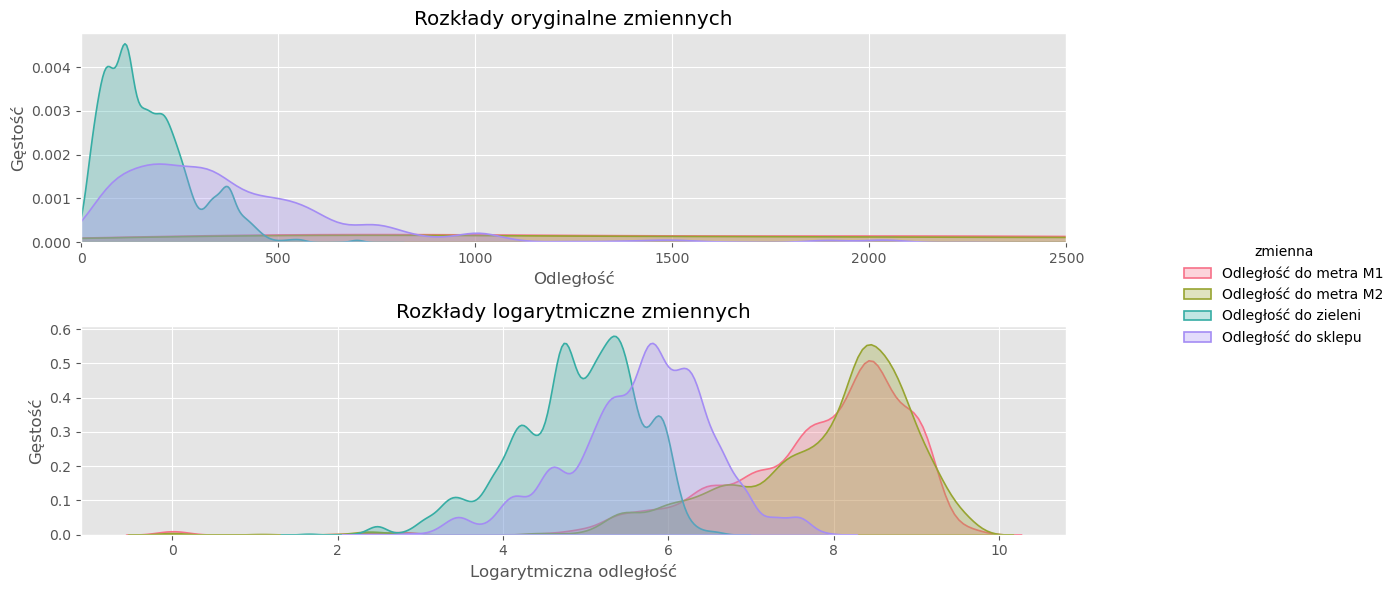

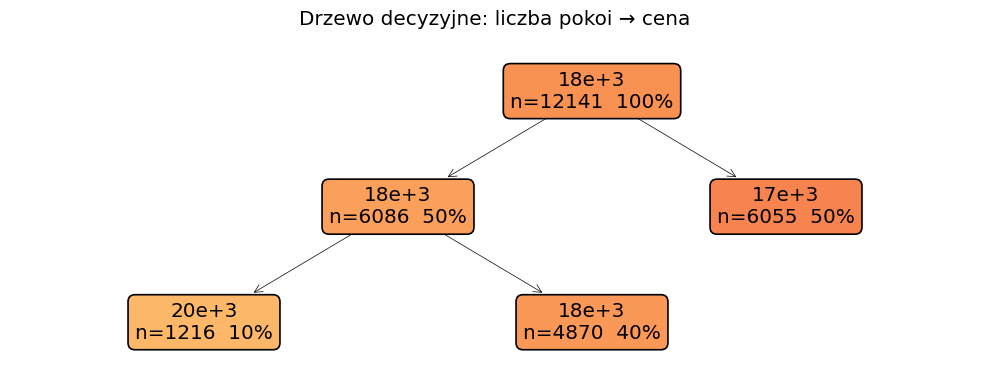

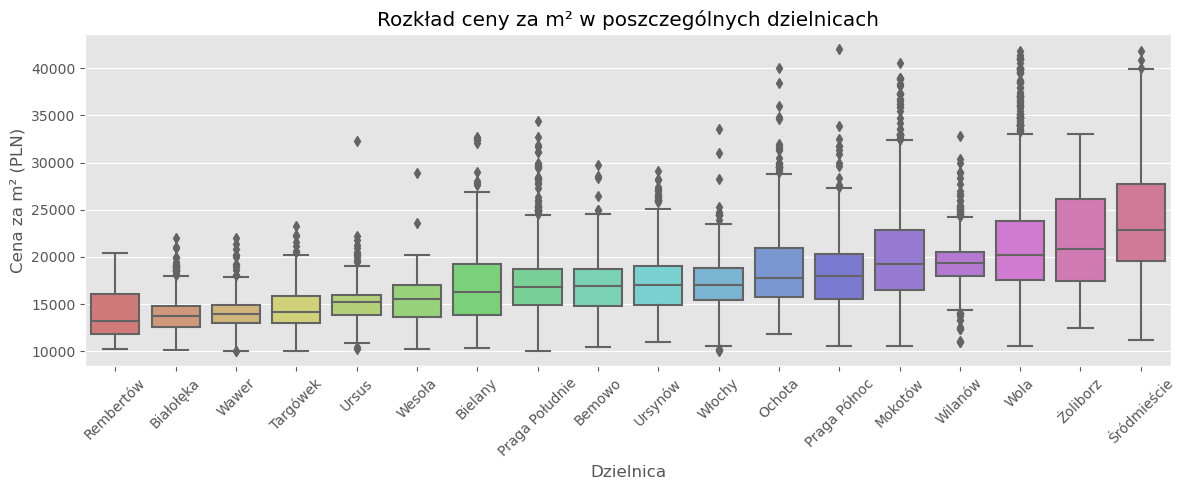

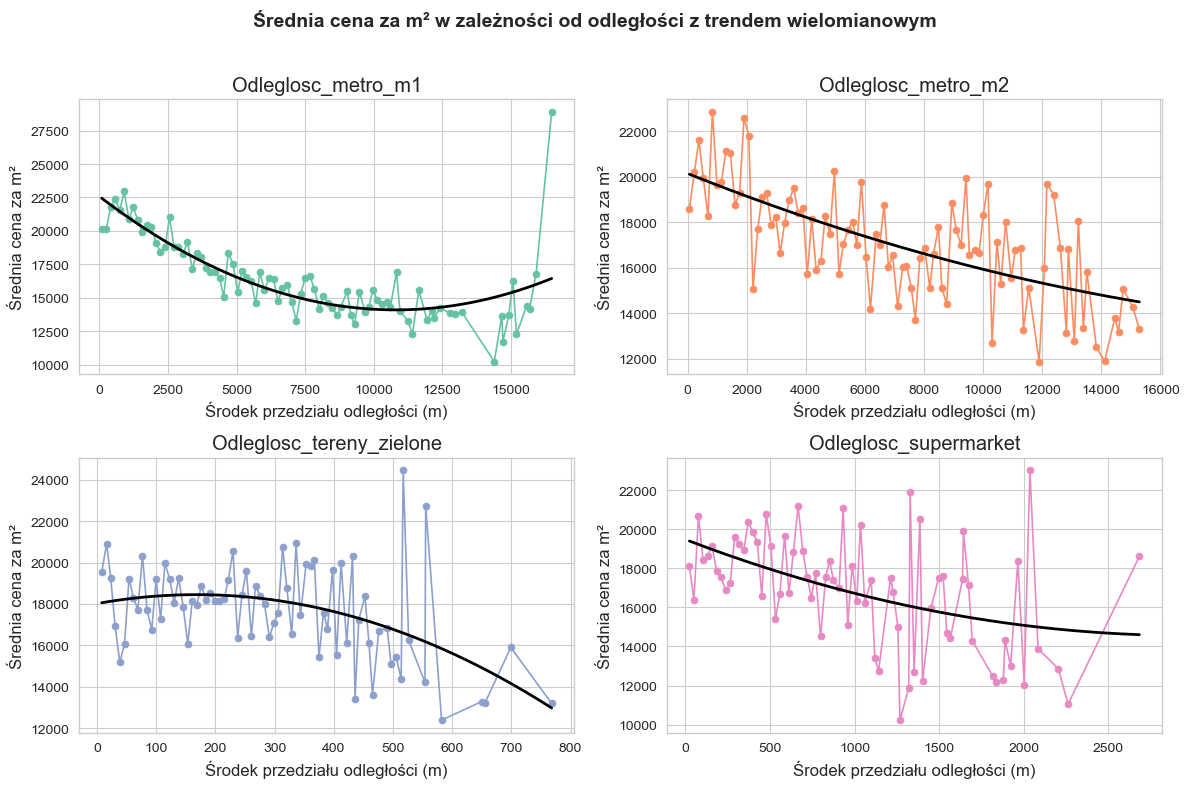

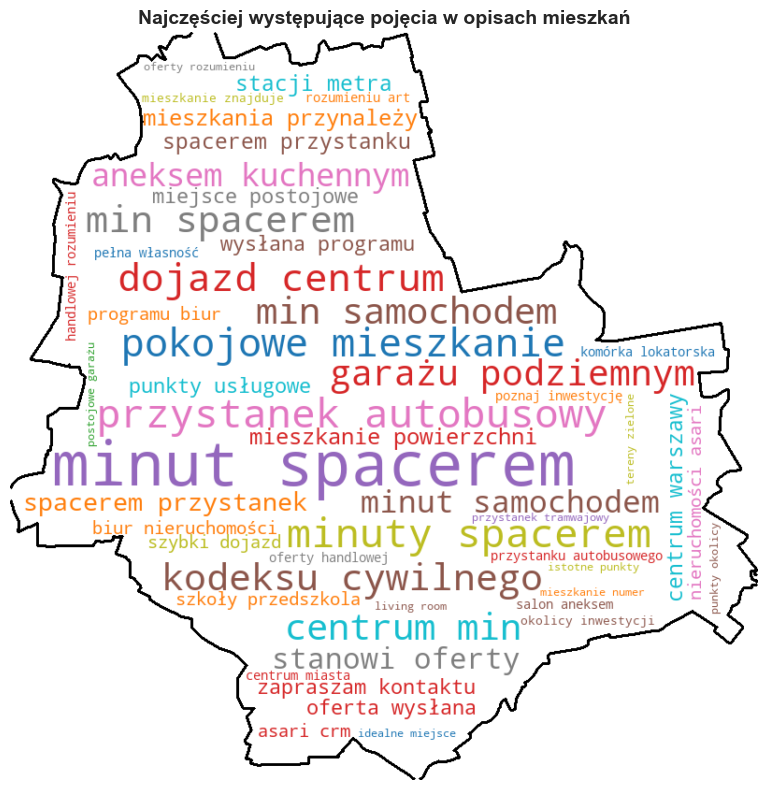

In [6]:
CFG = {
  # ============================================================
  # Filtry 
  # ============================================================
  "Filters": {
    # mapowanie wartości  
    "map_values": {
                    "Liczba pokoi": {
                      "more": 11
                    }
    },

    # konwersja braków danych
    "to_nan": ["brak danych"],

    # porzucenie kolumn
    "drop_columns": ["Czynsz", "Informacje dodatkowe", "proba_geokodowania", "Tytuł"],

    # porzucenie wierszy w których przynajmniej jedna z wartości jest brakująca
    "drop_na": ["Cena_za_m2", "Szerokosc_geo", "Dlugosc_geo", "Dzielnica" ,
                 "Odleglosc_metro_m1", "Odleglosc_metro_m2", "Odleglosc_tereny_zielone", "Odleglosc_supermarket"
                ],
    
    # wypełnienie wartości brakujących
    "fill_na": {
      "Stan wykończenia": "Stan wykończenia nieznany",
      "Rynek" : "Rynek nieznany"
    
    # upewnienie się co do typu danych
    },

    "astype": {
      "Cena_za_m2": "float",
      "Cena": "float",
      "Powierzchnia": "float",
      "Rok budowy": "float",
      "Piętro": "float",
      "Szerokosc_geo": "float",
      "Dlugosc_geo": "float",   
    },

    # imputacja medianowa
    "impute_median": ["Rok budowy", "Piętro", "Liczba pokoi"],
    
    # filtrowanie po zakresie 
    "range": {
      "Cena_za_m2": (10000, 42000),
      "Cena":     (382000, 4877600),
      "Powierzchnia":  (20, 170),
      "Rok budowy":    (1860, 2027),
    }
  },

  # ============================================================
  # Wizualizacje
  # ============================================================
  "visualizations": [
    
    # mapa izoliniowa cen mieszkań w Warszawie
    ("warsaw_price_isolines", {"grid": 250}, "10_warsaw_price_isolines"),
    
    # wykres violinowy roku budowy
    ("violin_price_by_year_jenks",
      {"year_col": "Rok budowy", "n_groups": 3},
      "11_violin_built_year"),
    
    # wykresy gęstości ceny z podziałem na stan wykończenia
    ("joyplot_price_by_finish_state",
      {
        "group_col": "Stan wykończenia",
        "value_col": "Cena_za_m2",
        "label_map": {
            "brak informacji": "brak informacji",
            "do remontu": "do remontu",
            "do wykończenia": "do wykończenia",
            "do zamieszkania": "gotowe do zamieszkania",
        }
      },
      "12_finish_state"),

    # barplot udogodnień
    ("amenities_frequency_bar_hue",
      {
        "amenities_cols":  ['balkon',
                            'boiska_sportowe', 'czujnik_dymu', 'domofon', 'drzwi', 'dwupoziomowe',
                            'garaz', 'internet', 'klimatyzacja', 'komorki_lokatorskie', 'kuchenka',
                            'lodowka', 'meble', 'miejsce_parkingowe', 'miejsce_parkingowe_naziemne',
                            'miejsce_parkingowe_podziemne', 'monitoring', 'ochrona',
                            'oddzielna_kuchnia', 'ogrodek', 'okna_antywlamaniowe', 'piekarnik',
                            'piwnica', 'plac_zbaw', 'pom_uzytkowe', 'pomieszczenie_na_rowery',
                            'pralka', 'przyjazny_dla_osob_niepelnosprawnych',
                            'rolety_antywlamaniowe', 'silownia', 'strefa_wypoczynku',
                            'system_alarmowy', 'taras', 'telefon', 'telewizja_kablowa', 'telewizor',
                            'teren_zamkniety', 'wideofon', 'winda', 'zmywarka']
        
        
        
        
        
        ,
        "min_frac": 0.05
      },
      "13_amenities_barplot"),

    # wykres odległości mieszkań od poszczególnych udogodnień
    ("distance_distributions_original_vs_log",
      {
        "cols": ["Odleglosc_metro_m1", "Odleglosc_metro_m2", "Odleglosc_tereny_zielone", "Odleglosc_supermarket"],
        "label_map": {
          "Odleglosc_metro_m1": "Odległość do metra M1",
          "Odleglosc_metro_m2": "Odległość do metra M2",
          "Odleglosc_supermarket":  "Odległość do sklepu",
          "Odleglosc_tereny_zielone":    "Odległość do zieleni",
        },
        "xlim": (0, 2500),
      },
      "14_dist_density_orig_vs_log"),

    # drzewo decyzyjne ceny za metr kwadratowy z podziałem na liczbe pokoi
    (
    "decision_tree_rooms_price",
      {
          "feature_col": "Liczba pokoi",
          "target_col": "Cena_za_m2",
          "n_categories": 3,   
      },
      "15_rooms_price_categories",
      ),

    # boxplot ceny z podziałem na dzielnice
    (
    "boxplot_price_by_district",
      {
          "district_col": "Dzielnica",
          "value_col": "Cena_za_m2",
      },
      "16_boxplot_price_by_district",
      ),

    # średnia cena wraz ze wzrostem odległości z trendem wielomianowym
    (
      "mean_price_vs_distance_poly2",
      {
        "distance_cols": [
          "Odleglosc_metro_m1", "Odleglosc_metro_m2", "Odleglosc_tereny_zielone", "Odleglosc_supermarket"
        ],
        "price_col": "Cena_za_m2",
        "bins": 100,
        "poly_degree": 2,
        "title": "Średnia cena za m² w zależności od odległości z trendem wielomianowym",
      },
      "17_mean_price_distance_poly"
      ),
    
    # chmura słów występujących w opisach
    (
      "warsaw_wordcloud",
      {
        "text_col": "Opis",             
        "geojson_path": "geojson/warsaw_districts.geojson",
        "max_words": 50,
      },
      "18_warsaw_wordcloud"
      ),

  ]

}

run_from_bundle(bundle, CFG);
bundle.set("data_filtered", apply_filters(bundle.get("data"), CFG.get("Filters", {})))

# Machine learning

In [7]:
bundle.get("data_filtered").head()

,Cena,Liczba pokoi,Opis,Piętro,Powierzchnia,Rok budowy,Rynek,Stan wykończenia,Szerokosc_geo,Dlugosc_geo,Odleglosc_metro_m1,Odleglosc_metro_m2,Odleglosc_tereny_zielone,Odleglosc_supermarket,Dzielnica,Cena_za_m2,balkon,boiska_sportowe,czujnik_dymu,domofon,drzwi,dwupoziomowe,garaz,internet,klimatyzacja,komorki_lokatorskie,kuchenka,lodowka,meble,miejsce_parkingowe,miejsce_parkingowe_naziemne,miejsce_parkingowe_podziemne,monitoring,ochrona,oddzielna_kuchnia,ogrodek,okna_antywlamaniowe,piekarnik,piwnica,plac_zbaw,pom_uzytkowe,pomieszczenie_na_rowery,pralka,przyjazny_dla_osob_niepelnosprawnych,rolety_antywlamaniowe,silownia,strefa_wypoczynku,system_alarmowy,taras,telefon,telewizja_kablowa,telewizor,teren_zamkniety,wideofon,winda,zmywarka
0,735000.0,3,"Jasne,słoneczne, wykończone, po remoncie miesz...",2.0,46.50,1970.0,wtórny,do zamieszkania,52.173802,21.003743,1541.658440,6417.386168,113.690515,25.362407,Mokotów,15806.451613,1,0,0,1,1,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,1
1,498000.0,1,"Jeśli szukasz gotowego, urządzonego lokalu do ...",1.0,31.22,2018.0,wtórny,do zamieszkania,52.186944,20.925278,6072.822653,5783.949230,171.962258,1240.248302,Włochy,15951.313261,0,0,0,0,0,0,1,0,0,0,1,1,1,1,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,999000.0,3,Mieszkanie gotowe do zamieszkania – ul. Jana K...,3.0,63.08,2017.0,wtórny,do zamieszkania,52.312820,21.051209,6642.540269,2311.987562,70.621785,558.382914,Białołęka,15837.032340,0,0,0,1,0,0,1,0,0,0,0,1,1,1,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1
3,755722.0,2,2-pokojowe mieszkanie numer 41 na 5. piętrze w...,5.0,43.81,2026.0,pierwotny,do wykończenia,52.240421,21.085254,5219.074896,2978.287597,236.044987,406.525938,Praga Południe,17249.988587,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,653000.0,3,Jeśli szukasz funkcjonalnego i jasnego mieszka...,2.0,48.39,1969.0,wtórny,do remontu,52.275063,21.082863,6323.784113,1708.494766,231.880529,756.388088,Targówek,13494.523662,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0


In [8]:
CFG_ML = {

    # ============================================================
    # EKSPERYMENT
    # ============================================================
    "experiment": {
        "target_col": "Cena_za_m2",
        "log_target": False,          
        "test_size": 0.20,
        "random_state": 42,
        "cv_folds": 5,
        "scoring": [
            "neg_mean_absolute_error",
            "neg_root_mean_squared_error",
            "r2",
        ],
    },

    # ============================================================
    # CECHY – PODZIAŁ STATYSTYCZNIE POPRAWNY
    # ============================================================
    "features": {

        # ----------------------------
        # ZMIENNE CIĄGŁE 
        # ----------------------------
        "continuous": [
            "Powierzchnia",
            "Odleglosc_metro_m1",
            "Odleglosc_metro_m2",
            "Odleglosc_tereny_zielone",
            "Odleglosc_supermarket"
        ],

        # ----------------------------
        # ZMIENNE PORZĄDKOWE 
        # ----------------------------
        "ordinal": [
            "Piętro",
            "Rok budowy",
        ],

        # ----------------------------
        # ZMIENNE KATEGORYCZNE NOMINALNE
        # ----------------------------
        "categorical": [
            "Dzielnica",
            "Stan wykończenia",
        ],

        # ----------------------------
        # ZMIENNE BINARNE (0/1)
        # ----------------------------
        "binary": [
                            'balkon',
                            'domofon', 'drzwi', 'garaz', 'internet', 'klimatyzacja',  'kuchenka',
                            'lodowka', 'meble', 'miejsce_parkingowe', 'monitoring', 'ochrona',
                            'oddzielna_kuchnia', 'ogrodek', 'okna_antywlamaniowe', 'piekarnik',
                            'piwnica',  'pom_uzytkowe', 'pralka', 'rolety_antywlamaniowe', 'system_alarmowy',
                            'taras', 'telefon', 'telewizja_kablowa', 'telewizor', 'teren_zamkniety',
                            'wideofon', 'winda', 'zmywarka'
        ],
    },

    # ============================================================
    # PREPROCESSING
    # ============================================================
    "preprocessing": {

        # --- skalowanie
        "scaling": {
            "method": "standard",          
            "apply_to": "all",      
        },

        # --- kodowanie
        "encoding": {
            "categorical": "onehot",       
            "drop_first": True,
        },

        # --- transformacje
        "log_transform": [
            "Odleglosc_metro_m1",
            "Odleglosc_metro_m2",
            "Odleglosc_tereny_zielone",
            "Odleglosc_supermarket"
        ],
    },

    "models": [

    # 1) RANDOM FOREST 
    {
        "name": "random_forest",
        "params": {
            "n_estimators": [150],
            "max_depth": [20],
            "max_features": ["sqrt"],
        },
    },

    # 2) XGBOOST 
    {
        "name": "xgboost",
        "params": {
            "learning_rate": [0.1],
            "max_depth": [7],
            "n_estimators": [200],
        },
    },

    # 3) SVR 
    {
        "name": "svr",
        "params": {
            "C": [1, 100, 1_000, 10_000],
            "epsilon": [25, 100,  400, 800],
            "kernel": ["rbf"],
            "gamma": ["scale", "auto"],
        },
    },

    # 4) DNN
    {
        "name": "dnn",
        "params": {
            "layers": [128, 64, 32],
            "activation": ["relu"],     
            "dropout": [0.3, 0.2, 0.0],
            "output_units": [1],
            "output_activation": ["linear"],
        },
    },
    ],  

    # ustawienia trenowania
    "training": {
                "optimizer": "adam",
                "epochs": 200,
                "batch_size": 16,
                "validation_split": 0.15,
                "early_stopping": {
                    "enabled": True,
                    "patience": 10,
                    "restore_best_weights": True,
                },
            },

}

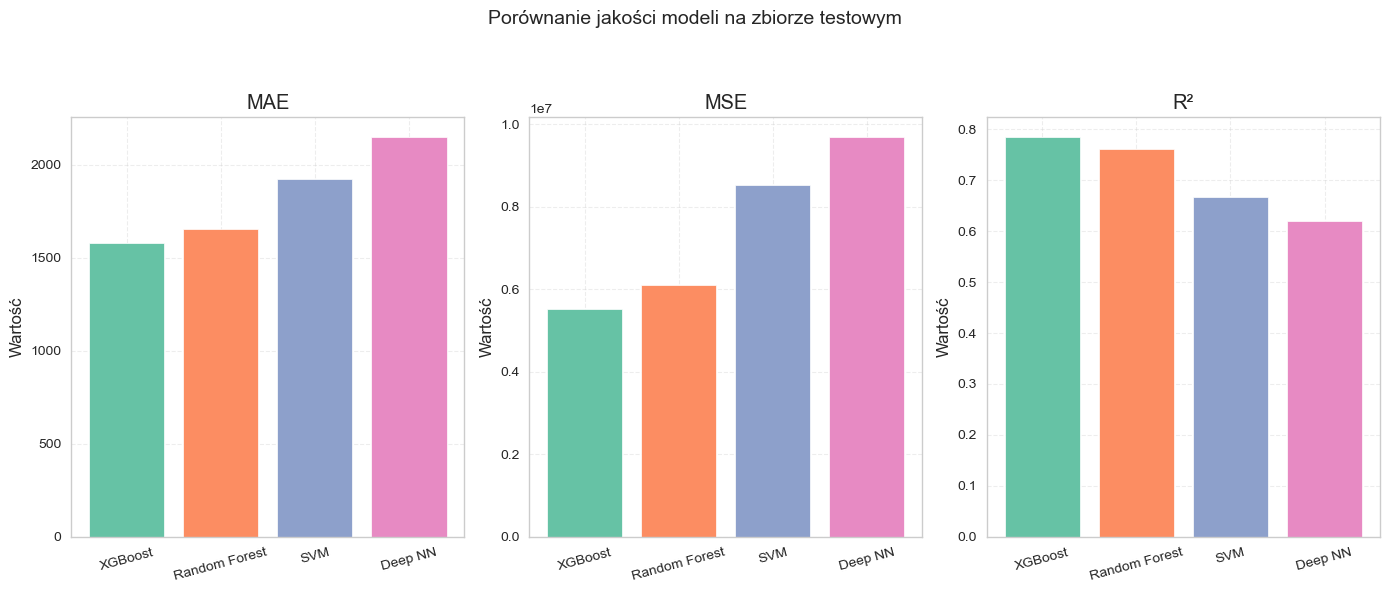

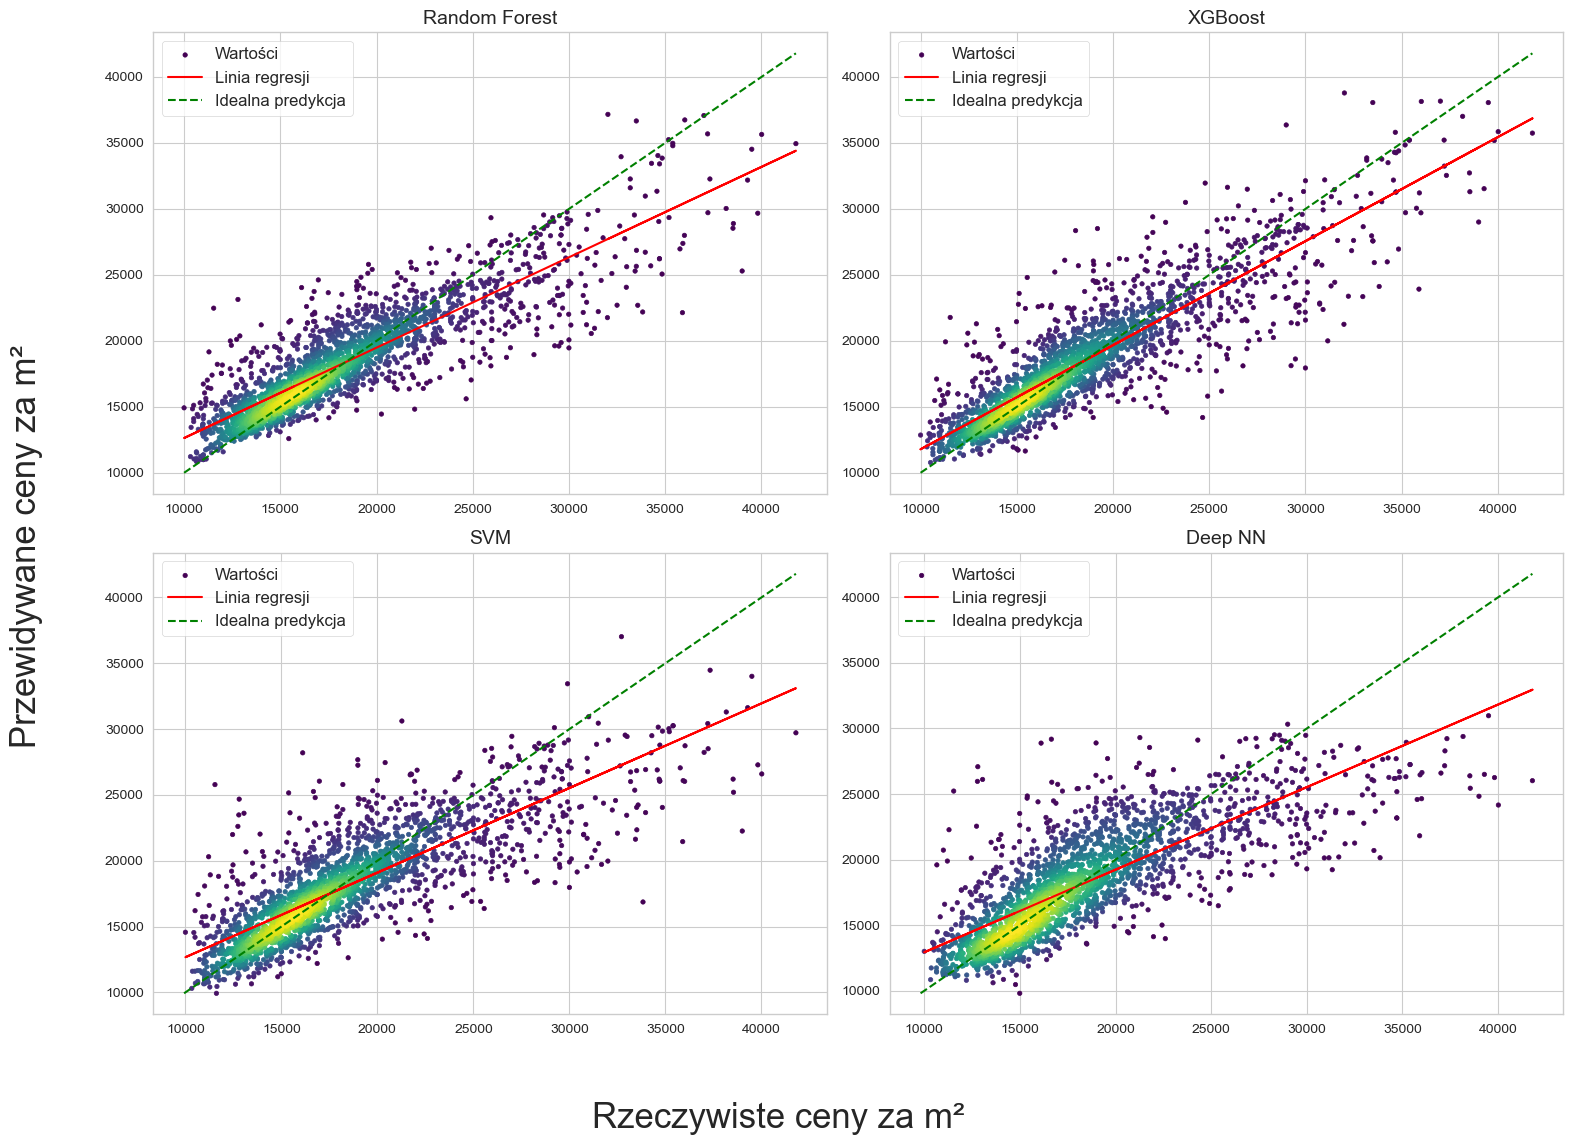

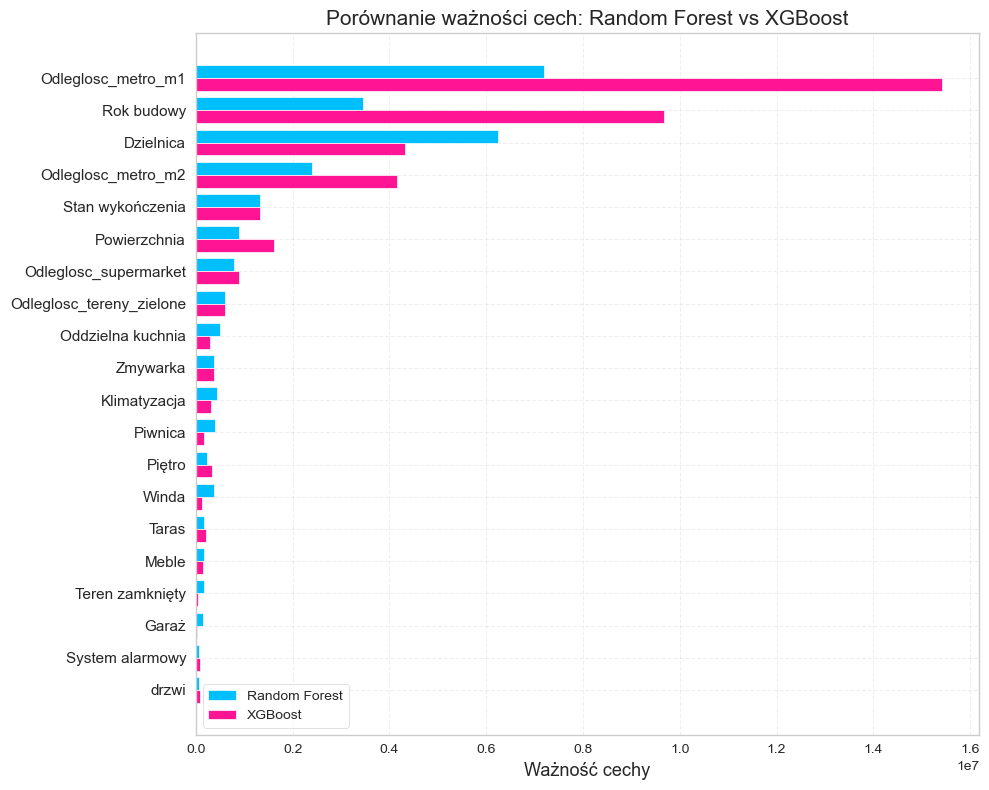

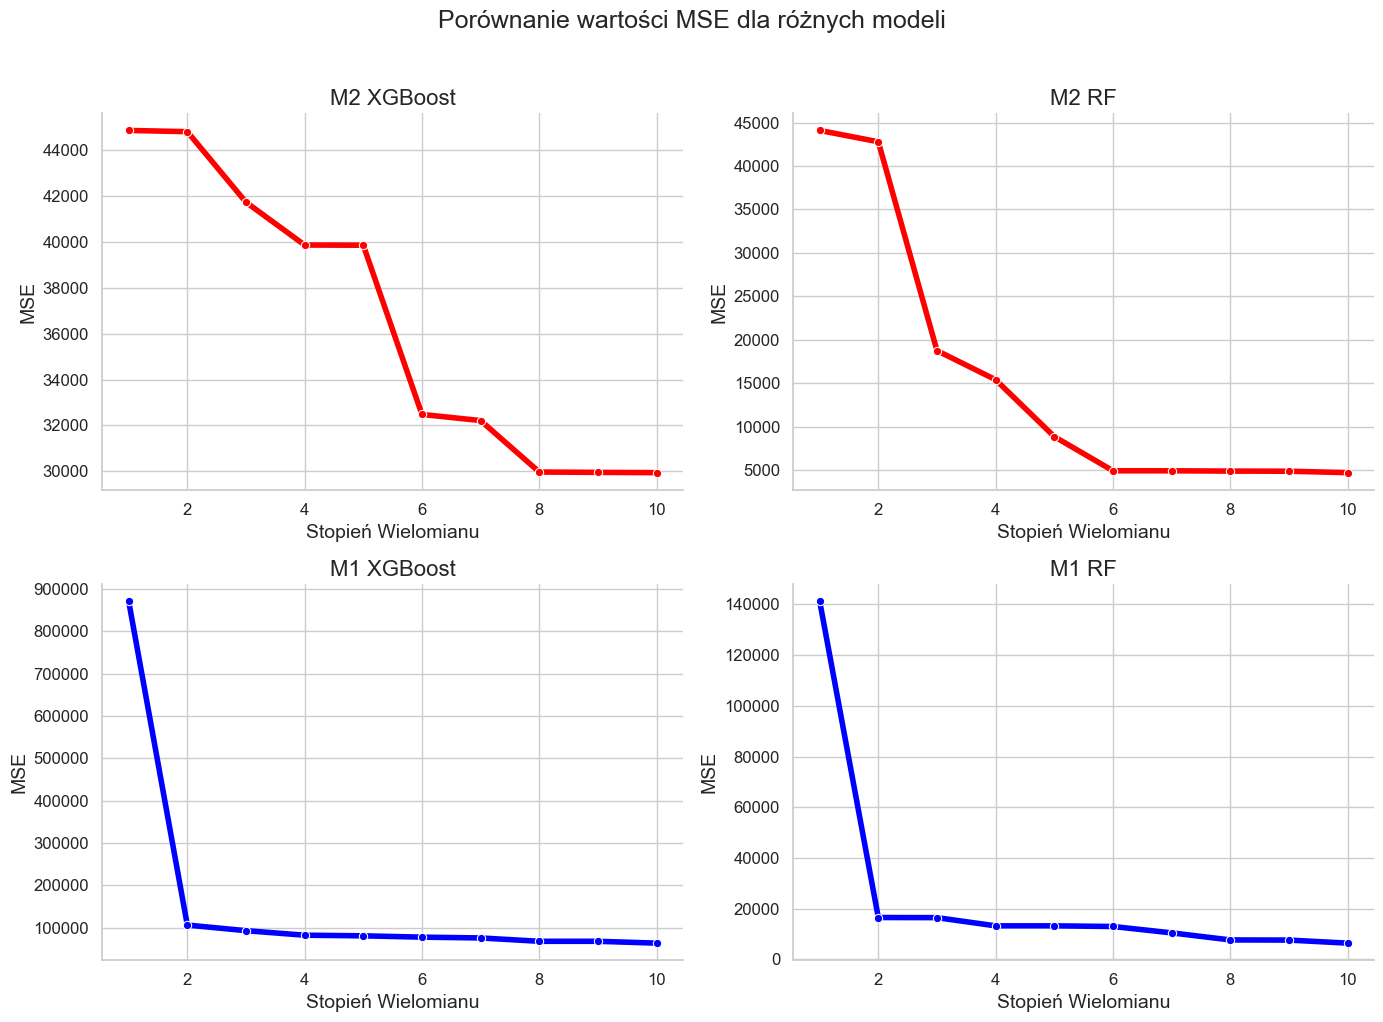

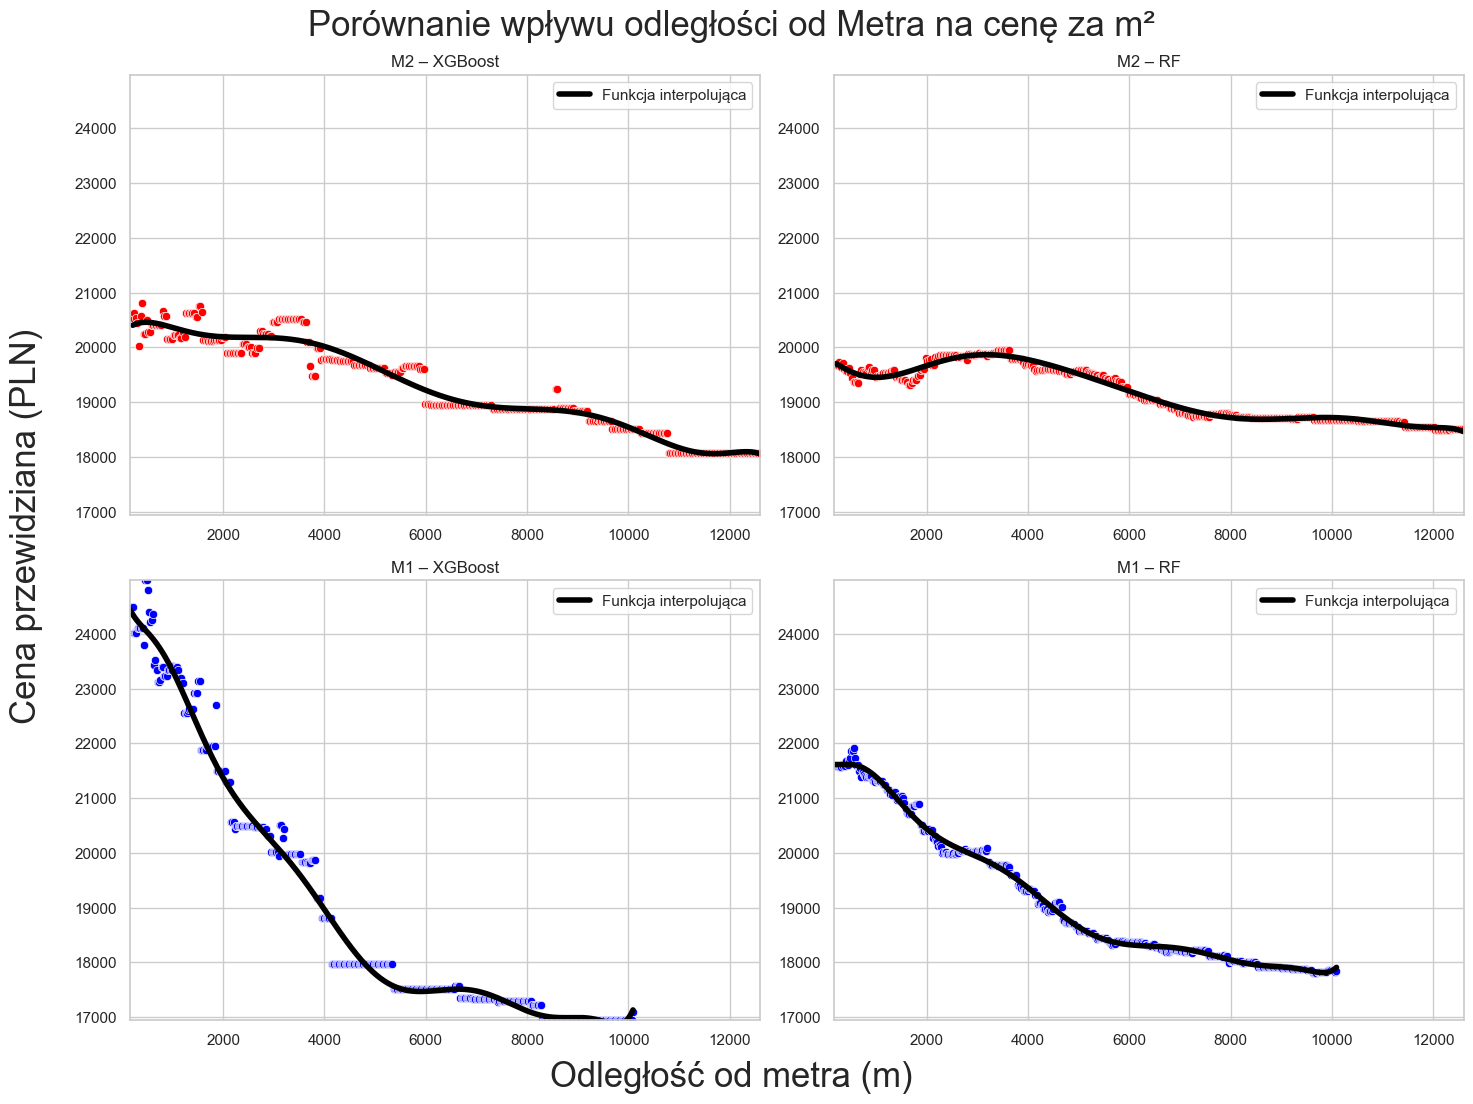

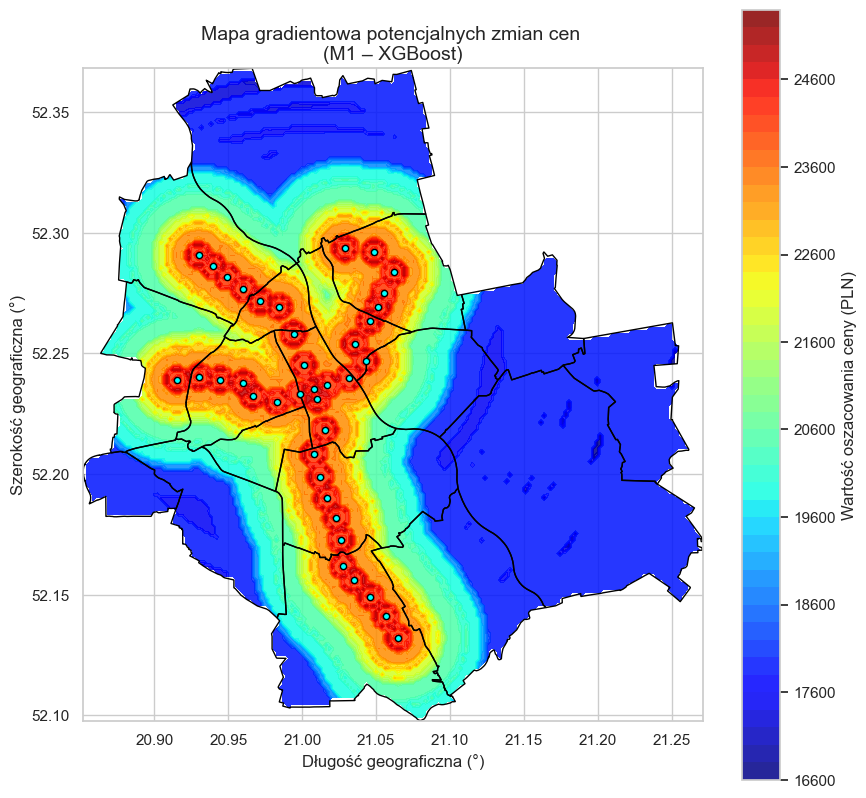

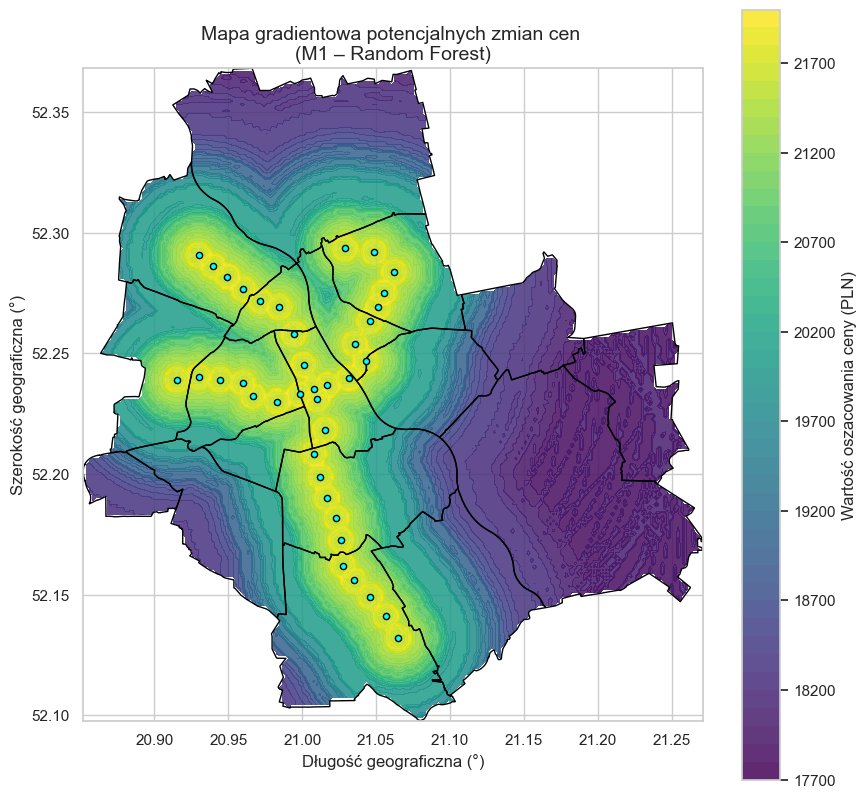

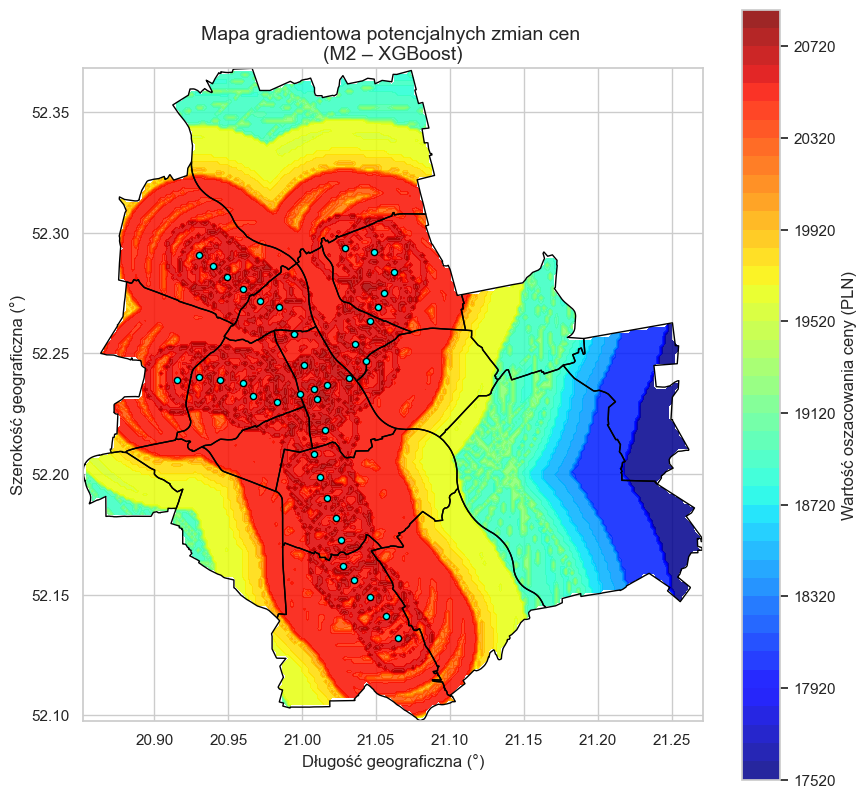

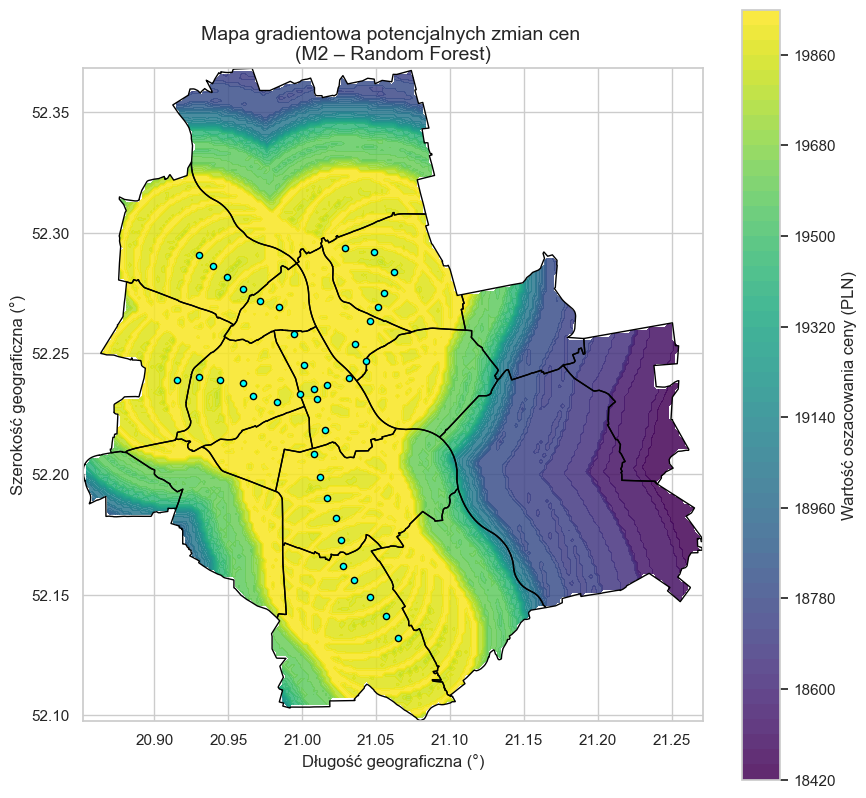

In [9]:
ml_pipe = Pipeline(bundle=bundle)

register_machine_learning_and_visualisations(
    ml_pipe,
    bundle=bundle,
    CFG=CFG_ML,
    on_table="data_filtered",
    artifacts_key="ml_artifacts",
    out_dir="visualizations",
)

ml_pipe.run()